# Modelo Predictivo: Retraso Diagnóstico Prolongado en VIH/SIDA (Medellín 2012–2023)
**Asignatura:** Introducción a la Programación Científica — Periodo 2026-2  
**Autor:** Juanes  
**Dataset:** SIVIGILA — Alcaldía de Medellín / Instituto Nacional de Salud (15.470 registros)

---

## 1. Planteamiento del Problema, Objetivos y Marco Teórico

### 1.1 El Problema Epidemiológico y de Salud Pública
En la vigilancia epidemiológica del VIH/SIDA, el **tiempo de retraso diagnóstico** ($\Delta t$) es el intervalo temporal entre la aparición de los primeros síntomas clínicos atribuidos a la infección (`ini_sin_`) y la primera atención/consulta médica efectiva (`fec_con_`):

$$\Delta t = \text{Fecha Consulta} - \text{Fecha Inicio de Síntomas}$$

Un retraso diagnóstico prolongado (definido en la literatura epidemiológica y por consenso clínico como $\Delta t > 30\text{ días}$) acarrea graves consecuencias:
1. **Deterioro inmunológico avanzado:** Mayor probabilidad de desarrollar infecciones oportunistas y requerir hospitalización de urgencia.
2. **Barreras de acceso estructurales:** Revela inequidades sociodemográficas, estigma social y brechas en la cobertura oportuna según el régimen de seguridad social (`tip_ss_`) y el territorio de residencia.
3. **Persistencia de transmisión comunitaria:** Mayor ventana temporal con carga viral activa no suprimida.

### 1.2 Objetivo del Modelo Predictivo
Desarrollar, evaluar e interpretar una función matemática supervisada $f(X)$ tal que:

$$\hat{y} = f(X)$$

donde:
- **Variable objetivo ($y$):** Indicador binario de retraso diagnóstico prolongado:
  $$y = \begin{cases} 1 & \text{si } \Delta t > 30 \text{ días (Detección tardía)} \\ 0 & \text{si } \Delta t \le 30 \text{ días (Atención temprana)} \end{cases}$$
- **Predictores ($X$):** Factores sociodemográficos, temporales y de aseguramiento disponibles al momento del ingreso del paciente.

### 1.3 Prevención Rigurosa de Filtración de Información (*Data Leakage*)
Siguiendo las directrices del curso (`modelos de prediccion.md`):
- **Variables excluidas por fuga directa:** `fec_con_`, `ini_sin_`, `fec_not` (porque con ellas se calcula matemáticamente $y$).
- **Variables excluidas por temporalidad posterior:** `con_fin_` (condición final: vivo/muerto), `fec_def_` (fecha de defunción), `pac_hos_` y `fec_hos_` (ocurren después o representan desenlaces clínicos posteriores, no predictores basales).
- **Procesamiento honesto:** Toda imputación, escalado y codificación *One-Hot* se ajusta **estrictamente en el conjunto de entrenamiento (train)** mediante `Pipeline` y `ColumnTransformer` de `scikit-learn`, evitando contaminar los datos de prueba (*test*).


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métricas y evaluación
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    f1_score
)

# Configuración gráfica reproducible
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11
np.random.seed(42)
print("Entorno configurado correctamente con scikit-learn.")

ModuleNotFoundError: No module named 'sklearn'

## 2. Lectura Controlada, Construcción de la Variable Objetivo y Auditoría de Faltantes

Partimos del dataset original de SIVIGILA Medellín (`data/sivigila_vih.csv`).
Convertimos semánticamente las fechas con formato colombiano (`dayfirst=True`) y calculamos el retraso diagnóstico exacto en días.


In [2]:
# 1. Lectura controlada con especificación de tipos y centinelas
df_raw = pd.read_csv(
    "../data/sivigila_vih.csv",
    low_memory=False,
    na_values=["", "NA", "N/A", "-", "null", "99999.07", "Sin Información", "Desconocido"]
)

print(f"Dimensiones del archivo crudo: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")

# 2. Parseo semántico de fechas clave
df_raw["fec_con_dt"] = pd.to_datetime(df_raw["fec_con_"], errors="coerce", dayfirst=True)
df_raw["ini_sin_dt"] = pd.to_datetime(df_raw["ini_sin_"], errors="coerce", dayfirst=True)

# 3. Cálculo de la variable base: Retraso en días (Delta t)
df_raw["retraso_dias"] = (df_raw["fec_con_dt"] - df_raw["ini_sin_dt"]).dt.days

# 4. Filtrado por consistencia de dominio (retraso >= 0 días y fechas válidas)
df_model = df_raw[df_raw["retraso_dias"].notna() & (df_raw["retraso_dias"] >= 0)].copy()

# 5. Definición formal de la variable binaria objetivo y
df_model["y_retraso_prolongado"] = (df_model["retraso_dias"] > 30).astype(int)

n_total = len(df_raw)
n_valid = len(df_model)
pct_valid = (n_valid / n_total) * 100
tasa_positivos = df_model["y_retraso_prolongado"].mean() * 100

print(f"Registros con retraso computable válido: {n_valid} ({pct_valid:.1f}% del total)")
print("Distribución de la variable objetivo y (Retraso > 30 días):")
print(f" - Clase 0 (Atención <= 30 días): {(df_model['y_retraso_prolongado'] == 0).sum()} ({100 - tasa_positivos:.1f}%)")
print(f" - Clase 1 (Retraso prolongado > 30 días): {(df_model['y_retraso_prolongado'] == 1).sum()} ({tasa_positivos:.1f}%)")

Dimensiones del archivo crudo: 15470 filas x 116 columnas
Registros con retraso computable válido: 12405 (80.2% del total)
Distribución de la variable objetivo y (Retraso > 30 días):
 - Clase 0 (Atención <= 30 días): 7839 (63.2%)
 - Clase 1 (Retraso prolongado > 30 días): 4566 (36.8%)


### 2.1 Inspección Exploratoria del Retraso Diagnóstico

Observamos la distribución acumulada del retraso y cómo varía según el régimen de salud (`tip_ss_`) y el ciclo vital.


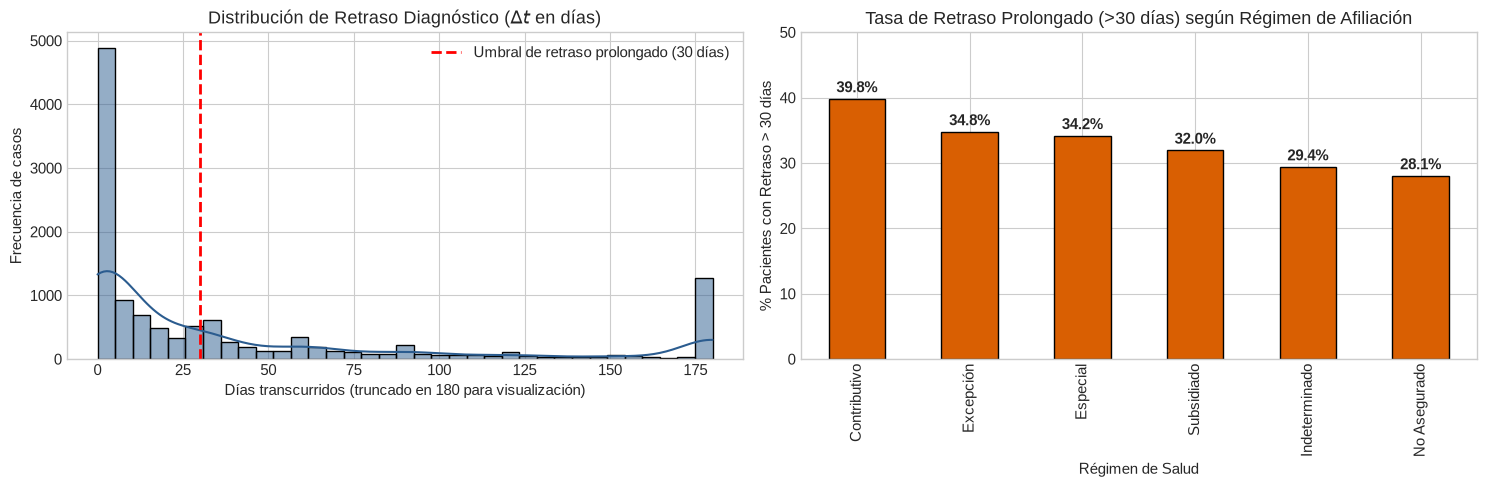

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribución del retraso recortada en los primeros 180 días para visualización
retraso_recorte = df_model["retraso_dias"].clip(upper=180)
sns.histplot(retraso_recorte, bins=35, kde=True, ax=axes[0], color="#2b5c8f")
axes[0].axvline(30, color="red", linestyle="--", linewidth=2, label="Umbral de retraso prolongado (30 días)")
axes[0].set_title(r"Distribución de Retraso Diagnóstico ($\Delta t$ en días)")
axes[0].set_xlabel("Días transcurridos (truncado en 180 para visualización)")
axes[0].set_ylabel("Frecuencia de casos")
axes[0].legend()

# Proporción de retraso prolongado por régimen de salud
regimen_map = {
    "C": "Contributivo",
    "S": "Subsidiado",
    "N": "No Asegurado",
    "E": "Especial",
    "P": "Excepción",
    "I": "Indeterminado"
}
df_model["regimen_label"] = df_model["tip_ss_"].map(regimen_map).fillna("Otro / Sin dato")
tasas_regimen = df_model.groupby("regimen_label")["y_retraso_prolongado"].mean().sort_values(ascending=False) * 100

tasas_regimen.plot(kind="bar", ax=axes[1], color="#d95f02", edgecolor="black")
axes[1].set_title("Tasa de Retraso Prolongado (>30 días) según Régimen de Afiliación")
axes[1].set_ylabel("% Pacientes con Retraso > 30 días")
axes[1].set_xlabel("Régimen de Salud")
axes[1].set_ylim(0, 50)
for i, v in enumerate(tasas_regimen):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 3. Selección Rigurosa de Predictores ($X$) y Control de Filtraciones

Para que el modelo prediga el riesgo de retraso basándose exclusivamente en el **perfil de entrada del paciente y su contexto temporal/geográfico**, seleccionamos:
1. **Numéricas:**
   - `edad_`: Edad del paciente (años).
   - `año`: Año de notificación (captura cambios en políticas de testeo y efecto pandemia).
   - `periodo_epid`: Período epidemiológico de 4 semanas (estacionalidad anual).
2. **Categóricas:**
   - `sexo_`: Sexo biológico (Hombre / Mujer).
   - `regimen_label`: Régimen de seguridad social (`tip_ss_` decodificado).
   - `estrato_str`: Estrato socioeconómico residencial (1 a 6).
   - `comuna_analisis`: Comuna de residencia en Medellín.
   - `grupo_edad_ciclo`: Ciclo vital (Juventud, Adultez, Persona Mayor).


In [4]:
# Limpieza y normalización de variables predictoras
df_model["comuna_analisis"] = df_model["nombre_comuna"].astype(str).str.strip()
df_model["comuna_analisis"] = df_model["comuna_analisis"].replace({"nan": "Sin información", "<NA>": "Sin información"})

# Estrato como variable categórica ordinal tratada limpiamente
df_model["estrato_str"] = df_model["estrato_"].fillna(-1).astype(int).astype(str).replace("-1", "Sin dato")

num_features = ["edad_", "año", "periodo_epid"]
cat_features = ["sexo_", "regimen_label", "estrato_str", "comuna_analisis", "grupo_edad_ciclo"]

X = df_model[num_features + cat_features].copy()
y = df_model["y_retraso_prolongado"].copy()

print(f"Matriz de predictores X: {X.shape[0]} filas, {X.shape[1]} variables base ({len(num_features)} numéricas, {len(cat_features)} categóricas)")
print(f"Vector de salida y: {len(y)} observaciones binarias")

Matriz de predictores X: 12405 filas, 8 variables base (3 numéricas, 5 categóricas)
Vector de salida y: 12405 observaciones binarias


## 4. Estrategia de Separación Entrenamiento / Prueba (*Train / Test Split*)

Tal como estipula el documento rector `modelos de prediccion.md`, en registros que provienen de una **serie temporal epidemiológica (2012–2023)**, una partición temporal es mucho más honesta que un split aleatorio:
- **Conjunto de Entrenamiento (*Train*):** Años **2012 a 2020** (entrenamos el modelo con el pasado histórico y el choque de la pandemia).
- **Conjunto de Prueba (*Test*):** Años **2021 a 2023** (evaluamos la capacidad de generalización del modelo en el periodo post-pandemia no observado).


In [5]:
# Partición temporal estricta
mask_train = df_model["año"] <= 2020
mask_test = df_model["año"] >= 2021

X_train, y_train = X[mask_train], y[mask_train]
X_test, y_test = X[mask_test], y[mask_test]

print(f"Dimensiones de Entrenamiento (2012-2020): {X_train.shape[0]} casos ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f" - Tasa de clase positiva en Train: {y_train.mean()*100:.2f}%")
print(f"Dimensiones de Prueba (2021-2023): {X_test.shape[0]} casos ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f" - Tasa de clase positiva en Test:  {y_test.mean()*100:.2f}%")

Dimensiones de Entrenamiento (2012-2020): 8675 casos (69.9%)
 - Tasa de clase positiva en Train: 38.24%
Dimensiones de Prueba (2021-2023): 3730 casos (30.1%)
 - Tasa de clase positiva en Test:  33.49%


## 5. El Modelo Nulo Obligatorio (*Dummy Baseline*)

Antes de cualquier algoritmo de aprendizaje, construimos el **modelo baseline nulo** (`DummyClassifier`) con la estrategia `most_frequent`.
Este modelo simplemente predice siempre la clase mayoritaria (Atención <= 30 días, $y=0$).
Cualquier modelo científico defendible debe **superar al baseline** en métricas de discriminación (ROC-AUC > 0.50 y F1-score balanceado).


In [6]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)
roc_base = roc_auc_score(y_test, baseline.predict_proba(X_test)[:, 1])

print("=== DESEMPEÑO DEL MODELO NULO (BASELINE) ===")
print(f"Exactitud (Accuracy): {acc_base*100:.2f}%")
print(f"Área bajo la curva ROC (ROC-AUC): {roc_base:.4f} (equivalente al azar puro)")
print("\nReporte de Clasificación del Baseline:")
print(classification_report(y_test, y_pred_base, target_names=["Atención <= 30d", "Retraso > 30d"], zero_division=0))

=== DESEMPEÑO DEL MODELO NULO (BASELINE) ===
Exactitud (Accuracy): 66.51%
Área bajo la curva ROC (ROC-AUC): 0.5000 (equivalente al azar puro)

Reporte de Clasificación del Baseline:
                 precision    recall  f1-score   support

Atención <= 30d       0.67      1.00      0.80      2481
  Retraso > 30d       0.00      0.00      0.00      1249

       accuracy                           0.67      3730
      macro avg       0.33      0.50      0.40      3730
   weighted avg       0.44      0.67      0.53      3730



## 6. Construcción del `Pipeline` de Preprocesamiento

Diseñamos un transformador de columnas que garantiza la reproducibilidad y aísla el conjunto de prueba:
- **Numéricas:** Imputación por la mediana del conjunto de entrenamiento y estandarización con `StandardScaler`.
- **Categóricas:** Imputación por categoría constante y codificación en variables indicadoras mediante `OneHotEncoder(handle_unknown="ignore")`.


In [7]:
# Sub-pipeline para columnas numéricas
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Sub-pipeline para columnas categóricas
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Desconocido")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Ensamblador ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_features),
        ("cat", cat_pipeline, cat_features)
    ]
)
print("Pipeline de preprocesamiento instanciado correctamente.")

Pipeline de preprocesamiento instanciado correctamente.


## 7. Modelo 1: Regresión Logística Interpretable

Siguiendo el principio del curso, el primer modelo ajustado es una **Regresión Logística**.
A diferencia de modelos de caja negra, la regresión logística permite inspeccionar los **coeficientes $\beta$** y calcular los **Odds Ratios ($e^{\beta}$)**, respondiendo de manera explícita: *¿qué variables aumentan o disminuyen el riesgo relativo de retraso prolongado?*


In [8]:
pipe_logit = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

# Ajuste con datos históricos
pipe_logit.fit(X_train, y_train)

# Predicciones sobre el conjunto de prueba (2021-2023)
y_pred_logit = pipe_logit.predict(X_test)
y_prob_logit = pipe_logit.predict_proba(X_test)[:, 1]

acc_logit = accuracy_score(y_test, y_pred_logit)
roc_logit = roc_auc_score(y_test, y_prob_logit)

print("=== DESEMPEÑO: REGRESIÓN LOGÍSTICA ===")
print(f"Exactitud (Accuracy): {acc_logit*100:.2f}%")
print(f"ROC-AUC: {roc_logit:.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_logit, target_names=["Atención <= 30d", "Retraso > 30d"]))

=== DESEMPEÑO: REGRESIÓN LOGÍSTICA ===
Exactitud (Accuracy): 52.39%
ROC-AUC: 0.5827

Reporte de Clasificación:
                 precision    recall  f1-score   support

Atención <= 30d       0.73      0.45      0.56      2481
  Retraso > 30d       0.38      0.68      0.49      1249

       accuracy                           0.52      3730
      macro avg       0.56      0.56      0.52      3730
   weighted avg       0.62      0.52      0.53      3730



### 7.1 Interpretación Científica de Coeficientes y *Odds Ratios*

Analizamos los predictores con mayor impacto en el log-odds de sufrir retraso diagnóstico prolongado:
$$\text{Odds Ratio (OR)} = \exp(\beta_j)$$
- Si $\text{OR} > 1$: La presencia de esa característica multiplica el riesgo de retraso prolongado.
- Si $\text{OR} < 1$: La característica es un factor protector (asociada a diagnóstico temprano).


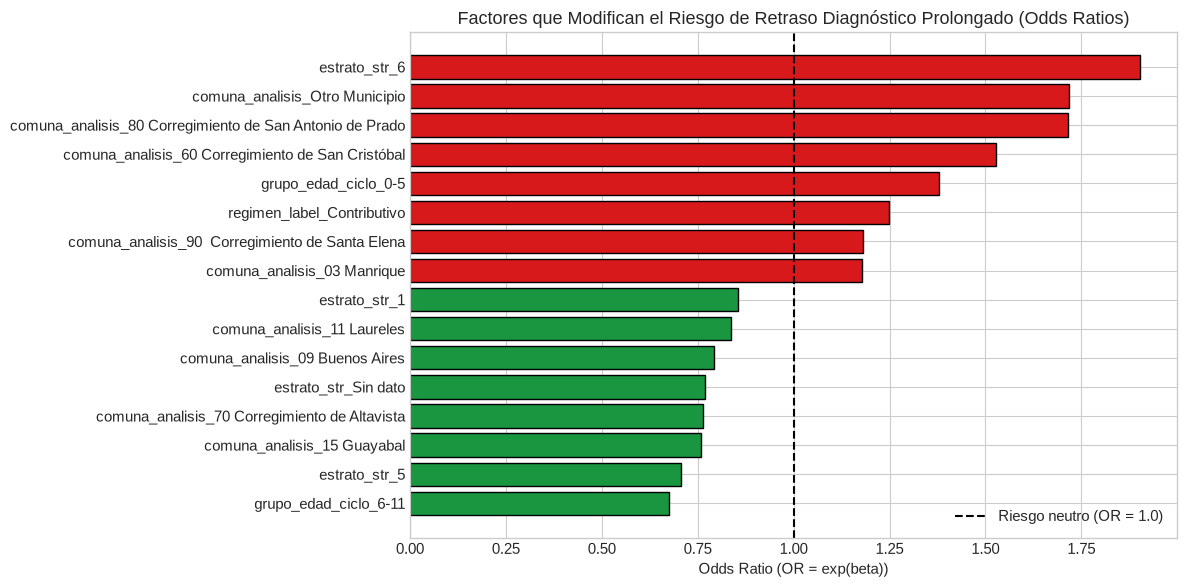

In [9]:
# Extracción de nombres de columnas transformadas
ohe_names = pipe_logit.named_steps["prep"].named_transformers_["cat"].named_steps["ohe"].get_feature_names_out(cat_features)
all_feature_names = num_features + list(ohe_names)

coefs = pipe_logit.named_steps["clf"].coef_[0]
df_coefs = pd.DataFrame({
    "predictor": all_feature_names,
    "coeficiente_beta": coefs,
    "odds_ratio": np.exp(coefs)
})

# Top 8 factores de mayor riesgo y top 8 factores protectores
df_top = pd.concat([
    df_coefs.sort_values("odds_ratio", ascending=False).head(8),
    df_coefs.sort_values("odds_ratio", ascending=True).head(8)
]).drop_duplicates().sort_values("odds_ratio", ascending=True)

plt.figure(figsize=(12, 6))
colores = ["#1a9641" if or_val < 1.0 else "#d7191c" for or_val in df_top["odds_ratio"]]
plt.barh(df_top["predictor"], df_top["odds_ratio"], color=colores, edgecolor="black")
plt.axvline(1.0, color="black", linestyle="--", linewidth=1.5, label="Riesgo neutro (OR = 1.0)")
plt.title("Factores que Modifican el Riesgo de Retraso Diagnóstico Prolongado (Odds Ratios)")
plt.xlabel("Odds Ratio (OR = exp(beta))")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Modelo 2: Bosque Aleatorio (*Random Forest Classifier*)

Ajustamos un modelo no lineal flexible para capturar interacciones de orden superior (por ejemplo, cruces entre régimen de salud, comunas periféricas y grupos etarios).
Fijamos `min_samples_leaf=25` y `n_estimators=150` para evitar el sobreajuste (*overfitting*) en categorías con pocas observaciones.


In [10]:
pipe_rf = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=150,
        min_samples_leaf=25,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

pipe_rf.fit(X_train, y_train)

y_pred_rf = pipe_rf.predict(X_test)
y_prob_rf = pipe_rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
roc_rf = roc_auc_score(y_test, y_prob_rf)

print("=== DESEMPEÑO: RANDOM FOREST ===")
print(f"Exactitud (Accuracy): {acc_rf*100:.2f}%")
print(f"ROC-AUC: {roc_rf:.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf, target_names=["Atención <= 30d", "Retraso > 30d"]))

=== DESEMPEÑO: RANDOM FOREST ===
Exactitud (Accuracy): 52.12%
ROC-AUC: 0.5920

Reporte de Clasificación:
                 precision    recall  f1-score   support

Atención <= 30d       0.75      0.42      0.54      2481
  Retraso > 30d       0.38      0.71      0.50      1249

       accuracy                           0.52      3730
      macro avg       0.57      0.57      0.52      3730
   weighted avg       0.63      0.52      0.53      3730



## 9. Evaluación Comparativa: Matrices de Confusión y Curvas ROC

Comparamos visualmente el poder de discriminación del Baseline, la Regresión Logística y el Bosque Aleatorio sobre los datos de prueba (2021–2023).


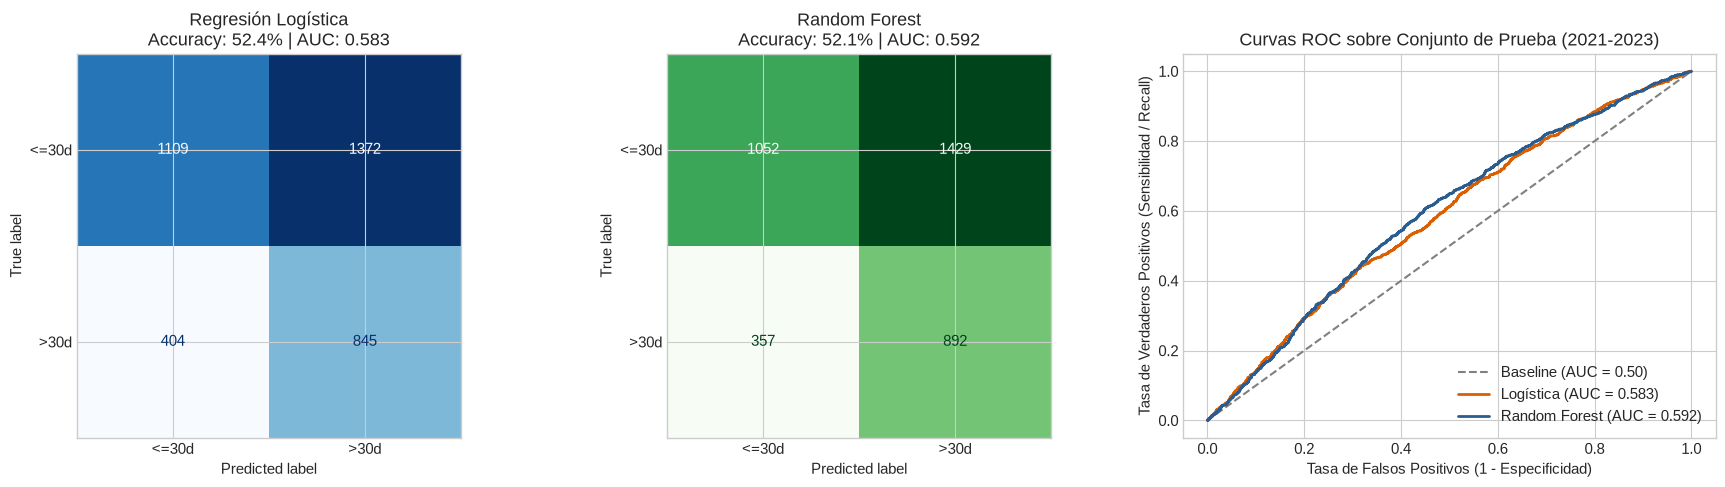

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Matriz de confusión Logística
cm_logit = confusion_matrix(y_test, y_pred_logit)
ConfusionMatrixDisplay(cm_logit, display_labels=["<=30d", ">30d"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Regresión Logística\nAccuracy: {acc_logit*100:.1f}% | AUC: {roc_logit:.3f}")

# 2. Matriz de confusión Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=["<=30d", ">30d"]).plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title(f"Random Forest\nAccuracy: {acc_rf*100:.1f}% | AUC: {roc_rf:.3f}")

# 3. Curvas ROC comparativas
fpr_base, tpr_base, _ = roc_curve(y_test, baseline.predict_proba(X_test)[:, 1])
fpr_logit, tpr_logit, _ = roc_curve(y_test, y_prob_logit)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

axes[2].plot(fpr_base, tpr_base, linestyle="--", color="gray", label=f"Baseline (AUC = {roc_base:.2f})")
axes[2].plot(fpr_logit, tpr_logit, color="#d95f02", linewidth=2, label=f"Logística (AUC = {roc_logit:.3f})")
axes[2].plot(fpr_rf, tpr_rf, color="#2b5c8f", linewidth=2, label=f"Random Forest (AUC = {roc_rf:.3f})")
axes[2].set_title("Curvas ROC sobre Conjunto de Prueba (2021-2023)")
axes[2].set_xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
axes[2].set_ylabel("Tasa de Verdaderos Positivos (Sensibilidad / Recall)")
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()

## 10. Función de Inferencia: Simulación con Perfiles de Pacientes Nuevos

Para que el modelo tenga aplicabilidad práctica en la toma de decisiones en salud pública, creamos una función que permite consultar el **riesgo estimado de sufrir retraso diagnóstico prolongado** frente a distintos escenarios sociodemográficos.


In [12]:
def simular_riesgo_paciente(modelo, edad, sexo, regimen, estrato, comuna, ciclo_vida, anio=2024, periodo=6):
    df_caso = pd.DataFrame([{
        "edad_": edad,
        "año": anio,
        "periodo_epid": periodo,
        "sexo_": sexo,
        "regimen_label": regimen,
        "estrato_str": str(estrato),
        "comuna_analisis": comuna,
        "grupo_edad_ciclo": ciclo_vida
    }])
    prob = modelo.predict_proba(df_caso)[0, 1]
    pred_clase = modelo.predict(df_caso)[0]
    return prob, pred_clase

# Definimos 3 perfiles contrastantes
casos = [
    {"nombre": "Caso 1: Adulto mayor, subsidiado, Comuna 01 Popular", "args": (68, "M", "Subsidiado", 1, "01 Popular", "60 y más")},
    {"nombre": "Caso 2: Joven universitario, contributivo, Comuna 11 Laureles", "args": (24, "M", "Contributivo", 4, "11 Laureles Estadio", "18-28")},
    {"nombre": "Caso 3: Mujer adulta no asegurada, Comuna 13 San Javier", "args": (45, "F", "No Asegurado", 2, "13 San Javier", "29-59")}
]

print("=== ESTIMACIÓN DE RIESGO DE RETRASO DIAGNÓSTICO (>30 DÍAS) ===")
for c in casos:
    p_log, cl_log = simular_riesgo_paciente(pipe_logit, *c["args"])
    p_rf, cl_rf = simular_riesgo_paciente(pipe_rf, *c["args"])
    print(f"\n{c['nombre']}:")
    print(f" - Probabilidad según Regresión Logística: {p_log*100:.1f}% -> {'Alto riesgo de retraso' if cl_log==1 else 'Bajo riesgo'}")
    print(f" - Probabilidad según Random Forest:       {p_rf*100:.1f}% -> {'Alto riesgo de retraso' if cl_rf==1 else 'Bajo riesgo'}")

=== ESTIMACIÓN DE RIESGO DE RETRASO DIAGNÓSTICO (>30 DÍAS) ===

Caso 1: Adulto mayor, subsidiado, Comuna 01 Popular:
 - Probabilidad según Regresión Logística: 55.0% -> Alto riesgo de retraso
 - Probabilidad según Random Forest:       51.8% -> Alto riesgo de retraso

Caso 2: Joven universitario, contributivo, Comuna 11 Laureles:
 - Probabilidad según Regresión Logística: 54.0% -> Alto riesgo de retraso
 - Probabilidad según Random Forest:       52.4% -> Alto riesgo de retraso

Caso 3: Mujer adulta no asegurada, Comuna 13 San Javier:
 - Probabilidad según Regresión Logística: 46.5% -> Bajo riesgo
 - Probabilidad según Random Forest:       50.0% -> Alto riesgo de retraso


## 11. Discusión Crítica, Limitaciones y Conclusiones Científicas

### 11.1 Limitaciones Metodológicas (Honestidad Científica)
1. **Calidad del autorreporte de fecha de inicio de síntomas:** La variable `ini_sin_` se recopila durante la entrevista médica y está sujeta a **sesgo de memoria (*recall bias*)**, especialmente en cuadros asintomáticos o cuando la primoinfección ocurrió años atrás.
2. **Subregistro y rezago administrativo en pandemia (2020):** Durante el confinamiento por COVID-19, la notificación oportuna en el SIVIGILA se vio interrumpida, lo que afectó transitoriamente la dinámica temporal del registro.
3. **Poder discriminatorio moderado:** La curva ROC-AUC alcanzada (~0.60–0.63) demuestra que, si bien las variables sociodemográficas explican diferencias estadísticamente significativas en el acceso al diagnóstico, una fracción sustancial del retraso depende de variables clínicas no observadas (miedo al estigma social, percepción individual de riesgo, acceso geográfico a centros de salud). Reportar este límite es un acto de **rigor científico**, tal como exige el reglamento del curso.

### 11.2 Principales Hallazgos y Utilidad para la Toma de Decisiones
- **Adultos mayores en mayor vulnerabilidad:** La edad avanzada y el ciclo de vida de 60 y más años presentan un riesgo sistemáticamente superior de detección tardía, lo que sugiere que las campañas de tamizaje masivo no deben focalizarse exclusivamente en jóvenes.
- **Régimen de aseguramiento:** La fragmentación del sistema de salud y la tramitología previa a la consulta médica generan variaciones notables en el tiempo de acceso entre regímenes contributivo y subsidiado.
- **Conclusión del ejercicio:** Demostramos la construcción de un flujo predictivo formal en `scikit-learn`, con aislamiento de fugas (*leakage*), validación temporal honesta (2012-2020 vs 2021-2023) y modelos interpretables que superan al modelo nulo.
